# Libraries

In [1]:
import pandas as pd
import pathlib
import json
import numpy as np
import nltk
import pickle
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Files 

In [2]:
skill_codes = pd.read_csv("../skills_code.csv", delimiter=",")
skill_codes_dict = skill_codes["skill"].to_dict()

In [3]:
skill_codes_dict = skill_codes["skill"].to_dict()
skill_codes_dict = {v:k for k,v in skill_codes_dict.items()}
skill_codes_dict["all_skills"]

0

## Computing the combined rules

In [4]:
prompts = sorted(list(pathlib.Path("../outputs/prompts").glob("*")))
prompts_object = dict()
prompts_dict = dict()
rules_plus_instances = dict()
# Initialize the total combined values 
total_emotions = 0
total_instances = 0
total_colors = 0
total_size = 0
total_spatial = 0
total_text = 0
# Loop through the files
for prompt_file in prompts:
    # Open each JSON prompt file
    with open(prompt_file, "rb") as file:
        # Load its contents
        prompts_object = json.load(file)
        # Loop through the prompts
        for prompt in prompts_object["prompts"]:
            # Get info
            skills = "+".join(prompt["skills"])
            level = prompt["level"]
            # Initializing prompt data
            num_emotions = 0
            num_instances = 0
            num_colors = 0
            num_size = 0
            num_spatial = 0
            num_text = 0
            # Check if emotions in synthetic prompt
            if "emotion" in prompt["scene"]:
                # Increase the emotions count
                num_emotions+=len(prompt["scene"]["emotion"])
            if "text" in prompt["scene"]:
                # Increase the text count
                num_text+=1
            # Check if objects in prompt
            if "objects" in prompt["scene"]:
                # Loop through the objects
                for object in prompt["scene"]["objects"]:
                    # Increase the object count
                    if "count" not in object:
                        num_instances+=1
                    else:
                        num_instances+=object["count"]
                    # Check if color included
                    if "color" in object:
                        num_colors+= object["count"] if "count" in object else (1+num_colors)
                    # Check if spatial_relations are included
                    if "spatial_relations" in prompt["scene"]:
                        for A, relationship, B in prompt["scene"]["spatial_relations"]:
                            num_spatial = (num_spatial + object["count"]) if "count" in object \
                            else  (num_spatial + 1)
                    # Check if spatial_relations are included
                    if "size_relations" in prompt["scene"]:
                        for A, relationship, B in prompt["scene"]["size_relations"]:
                            num_size = (num_size + object["count"]) if "count" in object \
                                else  (num_size + 1)
            if skills=="counting+color+spatial+size+emotion+text": 
                skills = "all_skills"
            skill_code = skill_codes_dict[skills]
            #print(skills,skill_code)
            # Loop through the synthetic prompts
            for i,synthetic_prompt in enumerate(prompt["synthetic_prompts"]):
                # Add to the dict
                if "robust" not in prompts_object["experiment_id"]:
                    prompts_dict[f"{skill_code}_{level}_001_{i}"] = synthetic_prompt
                    # Add the number of instances
                    rules_plus_instances[f"{skill_code}_{level}_001_{i}"] = num_instances
                    # Add the number of rules
                    rules_plus_instances[f"{skill_code}_{level}_001_{i}"]+=  (num_emotions + num_colors + num_size + num_spatial + num_text)
                    print(f"instances: {num_instances}, emotions: {num_emotions}, colors: {num_colors}, sizes: {num_size}, spatial: {num_spatial}, text: {num_text}")
                    # Spatial relationships

                else:
                    prompts_dict[f"{skill_code}_{level}_001_{i}_robust"] = synthetic_prompt
                    rules_plus_instances[f"{skill_code}_{level}_001_{i}_robust"] = num_instances + 1
                    rules_plus_instances[f"{skill_code}_{level}_001_{i}_robust"]+=  (num_emotions + num_colors + num_size + num_spatial + num_text)
            # Increase the totals
            total_emotions+=num_emotions
            total_instances+=num_instances
            total_colors+=num_colors
            total_size+=num_size
            total_spatial+=num_spatial
            total_text+=num_text

instances: 19, emotions: 3, colors: 19, sizes: 38, spatial: 38, text: 1
instances: 19, emotions: 3, colors: 19, sizes: 38, spatial: 38, text: 1
instances: 19, emotions: 3, colors: 19, sizes: 38, spatial: 38, text: 1
instances: 19, emotions: 3, colors: 19, sizes: 38, spatial: 38, text: 1
instances: 19, emotions: 3, colors: 19, sizes: 38, spatial: 38, text: 1
instances: 6, emotions: 2, colors: 6, sizes: 12, spatial: 12, text: 1
instances: 6, emotions: 2, colors: 6, sizes: 12, spatial: 12, text: 1
instances: 6, emotions: 2, colors: 6, sizes: 12, spatial: 12, text: 1
instances: 3, emotions: 1, colors: 3, sizes: 3, spatial: 3, text: 1
instances: 3, emotions: 1, colors: 3, sizes: 3, spatial: 3, text: 1
instances: 4, emotions: 3, colors: 15, sizes: 0, spatial: 0, text: 1
instances: 4, emotions: 3, colors: 15, sizes: 0, spatial: 0, text: 1
instances: 4, emotions: 3, colors: 15, sizes: 0, spatial: 0, text: 1
instances: 4, emotions: 3, colors: 15, sizes: 0, spatial: 0, text: 1
instances: 4, emot

In [5]:
print(f"Total emotions: {total_emotions}\n\
Total instances: {total_instances}\n\
Total colors: {total_colors}\n\
Total sizes: {total_size}\n\
Total spatial: {total_spatial}\n\
Total text: {total_text}")

Total emotions: 372
Total instances: 2228
Total colors: 1660
Total sizes: 2197
Total spatial: 2199
Total text: 186


In [6]:
for k,v in prompts_dict.items():
    print(f"{k} : {v}")
    print(rules_plus_instances["0_hard_001_0"])
    break

0_hard_001_0 : Five black toilets are arranged in a neat row on the left side of the room; to the right of them, five white bowls are arranged in a matching row so that every bowl is clearly positioned to the right of every toilet. Behind the foreground objects stand five oversized purple toothbrushes (taller and larger in scale than the white bowls), and in front of those toothbrushes are four small blue hot dogs placed closer to the viewer—each blue hot dog noticeably smaller than the black toilets. A small sign near the toilets reads "Toilet and hot dog: keep apart". Three people are visible: one person expressing trust with a warm smile and a hand gently resting on another person's shoulder, one person expressing disgust with a grimace and recoil while looking at a toilet, and one person expressing anticipation, leaning forward with bright eyes and hands slightly clasped while focused on a blue hot dog. The scene is well lit so all object colors, relative sizes, placements, and fac

# Utility function : extract features

In [7]:
RELATION_WORDS = {
    "with", "on", "under", "below", "above", "next",
    "beside", "between", "and", "or", "while", "which", "that"
}

In [8]:
def compute_lexical_diversity(tokens):
    return len(set(tokens))/len(tokens)

In [9]:
def extract_features(prompt):
    tokens = nltk.word_tokenize(prompt)
    pos_tags = nltk.pos_tag(tokens)

    length = len(tokens)

    num_nouns = sum(1 for w, t in pos_tags if t.startswith("NN"))
    num_adjectives = sum(1 for w, t in pos_tags if t.startswith("JJ"))
    num_prepositions = sum(1 for w, t in pos_tags if t == "IN")
    num_conjunctions = sum(1 for w, t in pos_tags if t == "CC")

    num_relations = sum(1 for w in tokens if w.lower() in RELATION_WORDS)

    num_clauses = sum(1 for w in tokens if w.lower() in {"which", "that", "while", "who", "when", "where"})
    num_sentences = len(nltk.sent_tokenize(prompt))
    parse_depth = num_clauses + num_sentences

    adjectives_density = num_adjectives / length if length else 0

    lexical_diversity = compute_lexical_diversity(tokens)

    # NEW FEATURES
    constraint_density = (num_relations + num_adjectives + num_prepositions) / max(length, 1)

    constraint_per_entity = (num_relations + num_adjectives) / max(num_nouns, 1)

    return {
        "length": length,
        "num_entities": num_nouns,
        "num_relations": num_relations,
        "parse_depth": parse_depth,
        "adjectives_density": adjectives_density,
        "num_prepositions": num_prepositions,
        "lexical_diversity": lexical_diversity,
        "num_conjunctions": num_conjunctions,
        "constraint_density": constraint_density,
        "constraint_per_entity": constraint_per_entity
    }

# Extracting features

In [10]:
rows = []

for key, prompt in prompts_dict.items():
    feats = extract_features(prompt)
    feats["id"] = key
    feats["level"] = key.split("_")[1]  # easy/medium/hard
    rows.append(feats)

df = pd.DataFrame(rows)

In [11]:
df["rules_plus_instances"] = rules_plus_instances.values()
df.head()

,length,num_entities,num_relations,parse_depth,adjectives_density,num_prepositions,lexical_diversity,num_conjunctions,constraint_density,constraint_per_entity,id,level,rules_plus_instances
0,197,52,17,8,0.131980,22,0.583756,8,0.329949,0.826923,0_hard_001_0,hard,118
1,175,49,14,6,0.137143,16,0.605714,8,0.308571,0.775510,0_hard_001_1,hard,118
2,120,30,9,5,0.133333,12,0.691667,4,0.308333,0.833333,0_hard_001_2,hard,118
3,169,45,10,5,0.153846,15,0.597633,7,0.301775,0.800000,0_hard_001_3,hard,118
4,135,34,11,4,0.148148,10,0.637037,7,0.303704,0.911765,0_hard_001_4,hard,118


In [12]:
df.groupby("level").describe()

length                                                           \
        count        mean        std   min   25%    50%     75%    max   
level                                                                    
easy    228.0   69.359649  25.787723  23.0  53.0   68.0   80.25  165.0   
hard    570.0  109.210526  40.163259  23.0  76.0  106.5  138.00  220.0   
medium  342.0   90.263158  33.682767  21.0  63.0   90.5  112.00  182.0   

       num_entities             ... constraint_per_entity            \
              count       mean  ...                   75%       max   
level                           ...                                   
easy          228.0  19.807018  ...              1.000000  1.833333   
hard          570.0  30.671930  ...              0.876913  2.500000   
medium        342.0  24.976608  ...              0.909091  1.750000   

       rules_plus_instances                                               \
                      count       mean        std  min   25%   50%   75%   
level                                                                      
easy                  228.0   8.456140   2.648715  3.0   7.0   8.0  10.0   
hard                  570.0  47.438596  29.010644  8.0  23.0  38.5  69.0   
medium                342.0  23.166667  10.960807  6.0  15.0  20.0  31.0   

               
          max  
level          
easy     17.0  
hard    118.0  
medium   56.0  

[3 rows x 88 columns]

In [13]:
df.columns

Index(['length', 'num_entities', 'num_relations', 'parse_depth',
       'adjectives_density', 'num_prepositions', 'lexical_diversity',
       'num_conjunctions', 'constraint_density', 'constraint_per_entity', 'id',
       'level', 'rules_plus_instances'],
      dtype='str')

In [14]:
len(df)

1140

In [15]:
df.groupby("level").describe()["length"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,69.359649,25.787723,23.0,53.0,68.0,80.25,165.0
hard,570.0,109.210526,40.163259,23.0,76.0,106.5,138.00,220.0
medium,342.0,90.263158,33.682767,21.0,63.0,90.5,112.00,182.0


<Axes: title={'center': 'length'}, xlabel='level'>

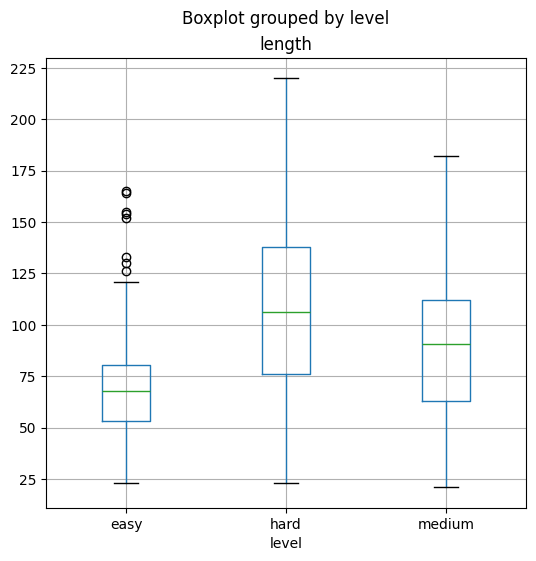

In [16]:
df.boxplot(by="level", column="length", figsize=(6,6), grid=True)

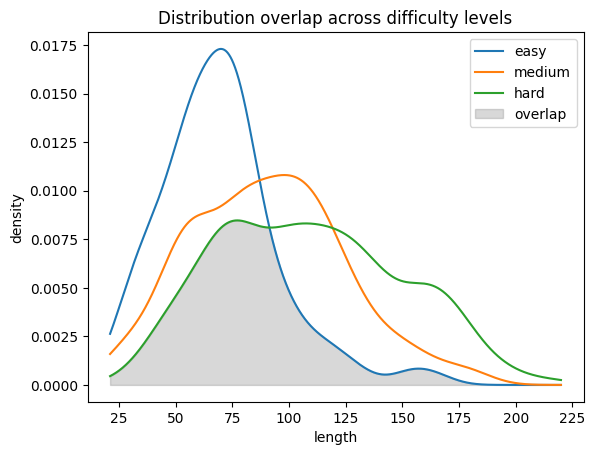

In [17]:
# Generating the set of points
x = np.linspace(df['length'].min(), df['length'].max(), 10000)
# Retrieving the values for each level
easy = df[df['level'] == 'easy']['length'].values
medium = df[df['level'] == 'medium']['length'].values
hard = df[df['level'] == 'hard']['length'].values
# Computing KDE for each level
kde_easy = gaussian_kde(easy)
kde_medium = gaussian_kde(medium)
kde_hard = gaussian_kde(hard)
# Computing 
d_easy = kde_easy(x)
d_medium = kde_medium(x)
d_hard = kde_hard(x)
# Overlap : pointwise minimum of the three
overlap = np.minimum(np.minimum(d_easy, d_medium), d_hard)
# Generating the plot
plt.plot(x, d_easy, label='easy')
plt.plot(x, d_medium, label='medium')
plt.plot(x, d_hard, label='hard')
plt.fill_between(x, overlap, color='gray', alpha=0.3, label='overlap')
plt.legend()
plt.xlabel("length")
plt.ylabel("density")
plt.title("Distribution overlap across difficulty levels")
plt.show()

In [18]:
# Threshold: top overlap region (top 25%)
threshold = np.percentile(overlap, 75)

# Indices of strong overlap
region = x[overlap >= threshold]

print("High-overlap interval:", region.min(), "to", region.max())
idx = np.argmax(overlap)
max_overlap = x[idx]

print(f"Max overlap at length: {max_overlap}.")

High-overlap interval: 50.71367136713671 to 100.44874487448745
Max overlap at length: 77.14351435143514.


# Cut-off point
The goal is to maximize overlap between subsets while keeping a balance between prompts by granular levels and prompt lengths.

In [19]:
df["analyze"] = df.length.apply(lambda x: x>=region.min() and x<=max_overlap)
df.head()

,length,num_entities,num_relations,parse_depth,adjectives_density,num_prepositions,lexical_diversity,num_conjunctions,constraint_density,constraint_per_entity,id,level,rules_plus_instances,analyze
0,197,52,17,8,0.131980,22,0.583756,8,0.329949,0.826923,0_hard_001_0,hard,118,False
1,175,49,14,6,0.137143,16,0.605714,8,0.308571,0.775510,0_hard_001_1,hard,118,False
2,120,30,9,5,0.133333,12,0.691667,4,0.308333,0.833333,0_hard_001_2,hard,118,False
3,169,45,10,5,0.153846,15,0.597633,7,0.301775,0.800000,0_hard_001_3,hard,118,False
4,135,34,11,4,0.148148,10,0.637037,7,0.303704,0.911765,0_hard_001_4,hard,118,False


# Get all the prompts to analyze

In [20]:
prompts_to_analyze = df[df["analyze"]==True]
prompts_to_analyze.head()

,length,num_entities,num_relations,parse_depth,adjectives_density,num_prepositions,lexical_diversity,num_conjunctions,constraint_density,constraint_per_entity,id,level,rules_plus_instances,analyze
9,70,18,6,3,0.128571,8,0.785714,3,0.328571,0.833333,0_easy_001_1,easy,14,True
18,56,14,6,3,0.214286,4,0.785714,2,0.392857,1.285714,0_easy_001_0_robust,easy,15,True
19,55,13,4,2,0.200000,3,0.763636,2,0.327273,1.153846,0_easy_001_1_robust,easy,15,True
27,71,20,6,6,0.126761,8,0.802817,1,0.323944,0.750000,2_medium_001_2,medium,13,True
28,59,17,7,2,0.152542,8,0.779661,2,0.406780,0.941176,2_easy_001_0,easy,7,True


In [21]:
with open("../prompts_to_analyze(length).pkl", "wb") as file:
        pickle.dump(list(prompts_to_analyze["id"]), file)

## Prompt lengths for our cutoff interval

> The aforementioned cutoff helped us to extract this specific interval, with mean and top 75% prompts lengths kinda similar across granular difficulty levels. 

In [22]:
prompts_to_analyze.groupby("level").describe()["length"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,65.379630,7.886719,51.0,58.0,66.0,73.0,77.0
hard,119.0,67.310924,7.502257,51.0,62.0,69.0,74.0,77.0
medium,89.0,63.157303,8.717666,51.0,56.0,60.0,72.0,77.0


In [23]:
df.head()

,length,num_entities,num_relations,parse_depth,adjectives_density,num_prepositions,lexical_diversity,num_conjunctions,constraint_density,constraint_per_entity,id,level,rules_plus_instances,analyze
0,197,52,17,8,0.131980,22,0.583756,8,0.329949,0.826923,0_hard_001_0,hard,118,False
1,175,49,14,6,0.137143,16,0.605714,8,0.308571,0.775510,0_hard_001_1,hard,118,False
2,120,30,9,5,0.133333,12,0.691667,4,0.308333,0.833333,0_hard_001_2,hard,118,False
3,169,45,10,5,0.153846,15,0.597633,7,0.301775,0.800000,0_hard_001_3,hard,118,False
4,135,34,11,4,0.148148,10,0.637037,7,0.303704,0.911765,0_hard_001_4,hard,118,False


In [24]:
prompts = list(df["id"])
lengths = list(df["length"])

lengths_data = {k:v for k,v in zip(prompts,lengths)}
with open("../lengths.pkl", "wb") as file:
    pickle.dump(lengths_data, file)

## Num entities (nouns)

In [25]:
prompts_to_analyze.head()

,length,num_entities,num_relations,parse_depth,adjectives_density,num_prepositions,lexical_diversity,num_conjunctions,constraint_density,constraint_per_entity,id,level,rules_plus_instances,analyze
9,70,18,6,3,0.128571,8,0.785714,3,0.328571,0.833333,0_easy_001_1,easy,14,True
18,56,14,6,3,0.214286,4,0.785714,2,0.392857,1.285714,0_easy_001_0_robust,easy,15,True
19,55,13,4,2,0.200000,3,0.763636,2,0.327273,1.153846,0_easy_001_1_robust,easy,15,True
27,71,20,6,6,0.126761,8,0.802817,1,0.323944,0.750000,2_medium_001_2,medium,13,True
28,59,17,7,2,0.152542,8,0.779661,2,0.406780,0.941176,2_easy_001_0,easy,7,True


### Original dataset

In [26]:
df.groupby("level").describe()["num_entities"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,19.807018,8.432554,5.0,14.0,19.0,24.0,55.0
hard,570.0,30.671930,11.718704,6.0,22.0,30.0,39.0,64.0
medium,342.0,24.976608,10.124998,5.0,17.0,25.0,31.0,56.0


### Our cutoff

In [27]:
prompts_to_analyze.groupby("level").describe()["num_entities"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,18.370370,3.705496,12.0,15.0,18.0,21.0,28.0
hard,119.0,18.941176,3.547007,11.0,17.0,19.0,22.0,27.0
medium,89.0,17.022472,3.136941,11.0,14.0,17.0,20.0,23.0


## Num relations

### Original dataset

In [28]:
df.groupby("level").describe()["num_relations"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,5.070175,2.503634,0.0,3.0,5.0,6.0,14.0
hard,570.0,8.615789,4.467193,0.0,5.0,8.0,12.0,21.0
medium,342.0,7.087719,3.673384,0.0,5.0,7.0,9.0,20.0


### Our cutoff

In [29]:
prompts_to_analyze.groupby("level").describe()["num_relations"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,4.787037,1.414550,2.0,4.0,5.0,6.0,9.0
hard,119.0,4.924370,2.017549,1.0,4.0,5.0,6.0,10.0
medium,89.0,4.662921,2.016657,0.0,3.0,5.0,6.0,10.0


## Parse depth

### Original dataset

In [30]:
df.groupby("level").describe()["parse_depth"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,2.381579,1.258981,1.0,1.0,2.0,3.0,7.0
hard,570.0,3.666667,1.670938,1.0,3.0,4.0,5.0,8.0
medium,342.0,3.461988,1.623694,1.0,2.0,3.0,5.0,8.0


### Our cutoff

In [31]:
prompts_to_analyze.groupby("level").describe()["parse_depth"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,2.370370,1.028497,1.0,1.0,2.0,3.0,5.0
hard,119.0,2.252101,1.001850,1.0,1.0,2.0,3.0,5.0
medium,89.0,2.471910,1.098448,1.0,2.0,2.0,3.0,6.0


## Adjectives density 

### Original dataset

In [32]:
df.groupby("level").describe()["adjectives_density"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,0.165098,0.043109,0.0,0.134467,0.166667,0.194066,0.275000
hard,570.0,0.135017,0.040015,0.0,0.111111,0.132490,0.158730,0.263158
medium,342.0,0.137343,0.042180,0.0,0.108155,0.135135,0.163544,0.269231


### Our cutoff

In [33]:
prompts_to_analyze.groupby("level").describe()["adjectives_density"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,0.169544,0.041022,0.080000,0.138329,0.169321,0.197069,0.254902
hard,119.0,0.146693,0.051506,0.015152,0.108849,0.144928,0.181818,0.257143
medium,89.0,0.147980,0.047371,0.034483,0.116883,0.138462,0.178571,0.269231


## Number of prepositions

### Original dataset

In [34]:
df.groupby("level").describe()["num_prepositions"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,7.311404,3.023324,2.0,5.0,7.0,9.0,16.0
hard,570.0,11.531579,4.746274,1.0,8.0,11.0,15.0,27.0
medium,342.0,9.956140,3.944015,1.0,7.0,10.0,13.0,22.0


### Our cutoff

In [35]:
prompts_to_analyze.groupby("level").describe()["num_prepositions"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,6.851852,1.812804,3.0,6.0,7.0,8.0,12.0
hard,119.0,7.226891,1.739067,3.0,6.0,7.0,8.0,11.0
medium,89.0,7.044944,1.930085,4.0,6.0,7.0,8.0,12.0


# Conjunctions

### Original dataset

In [36]:
df.groupby("level").describe()["num_conjunctions"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,1.956140,1.462545,0.0,1.0,2.0,2.25,8.0
hard,570.0,3.673684,2.395553,0.0,2.0,3.0,5.00,12.0
medium,342.0,3.248538,2.018880,0.0,2.0,3.0,4.00,10.0


### Our cutoff

In [37]:
prompts_to_analyze.groupby("level").describe()["num_conjunctions"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,1.712963,0.875961,0.0,1.0,2.0,2.0,5.0
hard,119.0,1.647059,1.161444,0.0,1.0,1.0,2.5,5.0
medium,89.0,1.887640,1.112309,0.0,1.0,2.0,3.0,4.0


# Constraint density

### Original dataset

In [38]:
df.groupby("level").describe()["constraint_density"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,0.344261,0.046989,0.200000,0.310810,0.345459,0.374185,0.466667
hard,570.0,0.317764,0.048827,0.156250,0.290088,0.318182,0.346154,0.481481
medium,342.0,0.326377,0.049190,0.151515,0.294118,0.324838,0.359628,0.461538


### Our cutoff

In [39]:
prompts_to_analyze.groupby("level").describe()["constraint_density"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,0.348246,0.049215,0.238806,0.314683,0.348485,0.386248,0.452830
hard,119.0,0.327621,0.063013,0.156250,0.288763,0.328358,0.377868,0.481481
medium,89.0,0.333044,0.057312,0.166667,0.293103,0.333333,0.372549,0.461538


# Constraint load per entity

### Original dataset

In [40]:
df.groupby("level").describe()["constraint_per_entity"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,228.0,0.857845,0.221634,0.25,0.714286,0.833333,1.000000,1.833333
hard,570.0,0.769862,0.212659,0.25,0.645636,0.750000,0.876913,2.500000
medium,342.0,0.793976,0.227029,0.00,0.647794,0.777778,0.909091,1.750000


### Our cutoff

In [41]:
prompts_to_analyze.groupby("level").describe()["constraint_per_entity"]

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
easy,108.0,0.886632,0.211548,0.360000,0.747283,0.857143,1.0,1.384615
hard,119.0,0.804879,0.272255,0.250000,0.613248,0.772727,1.0,1.727273
medium,89.0,0.837567,0.259865,0.294118,0.650000,0.800000,1.0,1.692308


# Save rules plus instances

In [23]:
A = " \nYou are wrong \n\n "
print(A)
print("----")
print(A.strip())

 
You are wrong 

 
----
You are wrong


In [7]:
import itertools
A = ["apple", "fire hyfrant", "test"]
list(itertools.combinations(A,2))

[('apple', 'fire hyfrant'), ('apple', 'test'), ('fire hyfrant', 'test')]

In [8]:
A = [True, True, False, False, True]
sum(A)/len(A)

0.6

In [ ]:
with open("../rules_plus_instances_2.pkl", "wb") as file:
    pickle.dump(rules_plus_instances,file)